# Common Libraries

In [1]:
import os, shutil
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
def get_moment_arm_matrix(model: mujoco.MjModel, data: mujoco.MjData) -> pd.DataFrame:
    """
    Get momentarm from current data ste

    :param model: mujoco model
    :param data: mujoco data

    :return: moment arm (shape: #muscle, #joint)
    """
    joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i) for i in range(model.njnt)]
    muscle_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, i) for i in range(model.nu)]

    n_muscle = len(muscle_names)
    n_joint = len(joint_names)
    
    # Update geometry
    mujoco.mj_fwdPosition(model, data) 

    AM = np.zeros((n_muscle, n_joint))
    mujoco.mju_sparse2dense(AM,
                            data.actuator_moment.reshape(-1),
                            data.moment_rownnz,
                            data.moment_rowadr,
                            data.moment_colind.reshape(-1))
    AM_df = pd.DataFrame(AM)
    AM_df.index = muscle_names
    AM_df.columns = joint_names
    return AM_df

# Params

In [3]:
model_path = "/home/seojin/biomechanics_tools/myo_sim/arm/myoarm.xml"

# Initialize model

In [4]:
model = mujoco.MjModel.from_xml_path(model_path)

mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Calculate moment arm

In [12]:
moment_arm = get_moment_arm_matrix(model, mj_data)
joint_names = moment_arm.index.to_numpy()
muscle_names = moment_arm.columns.to_numpy()

# Plot moment arm

<Axes: >

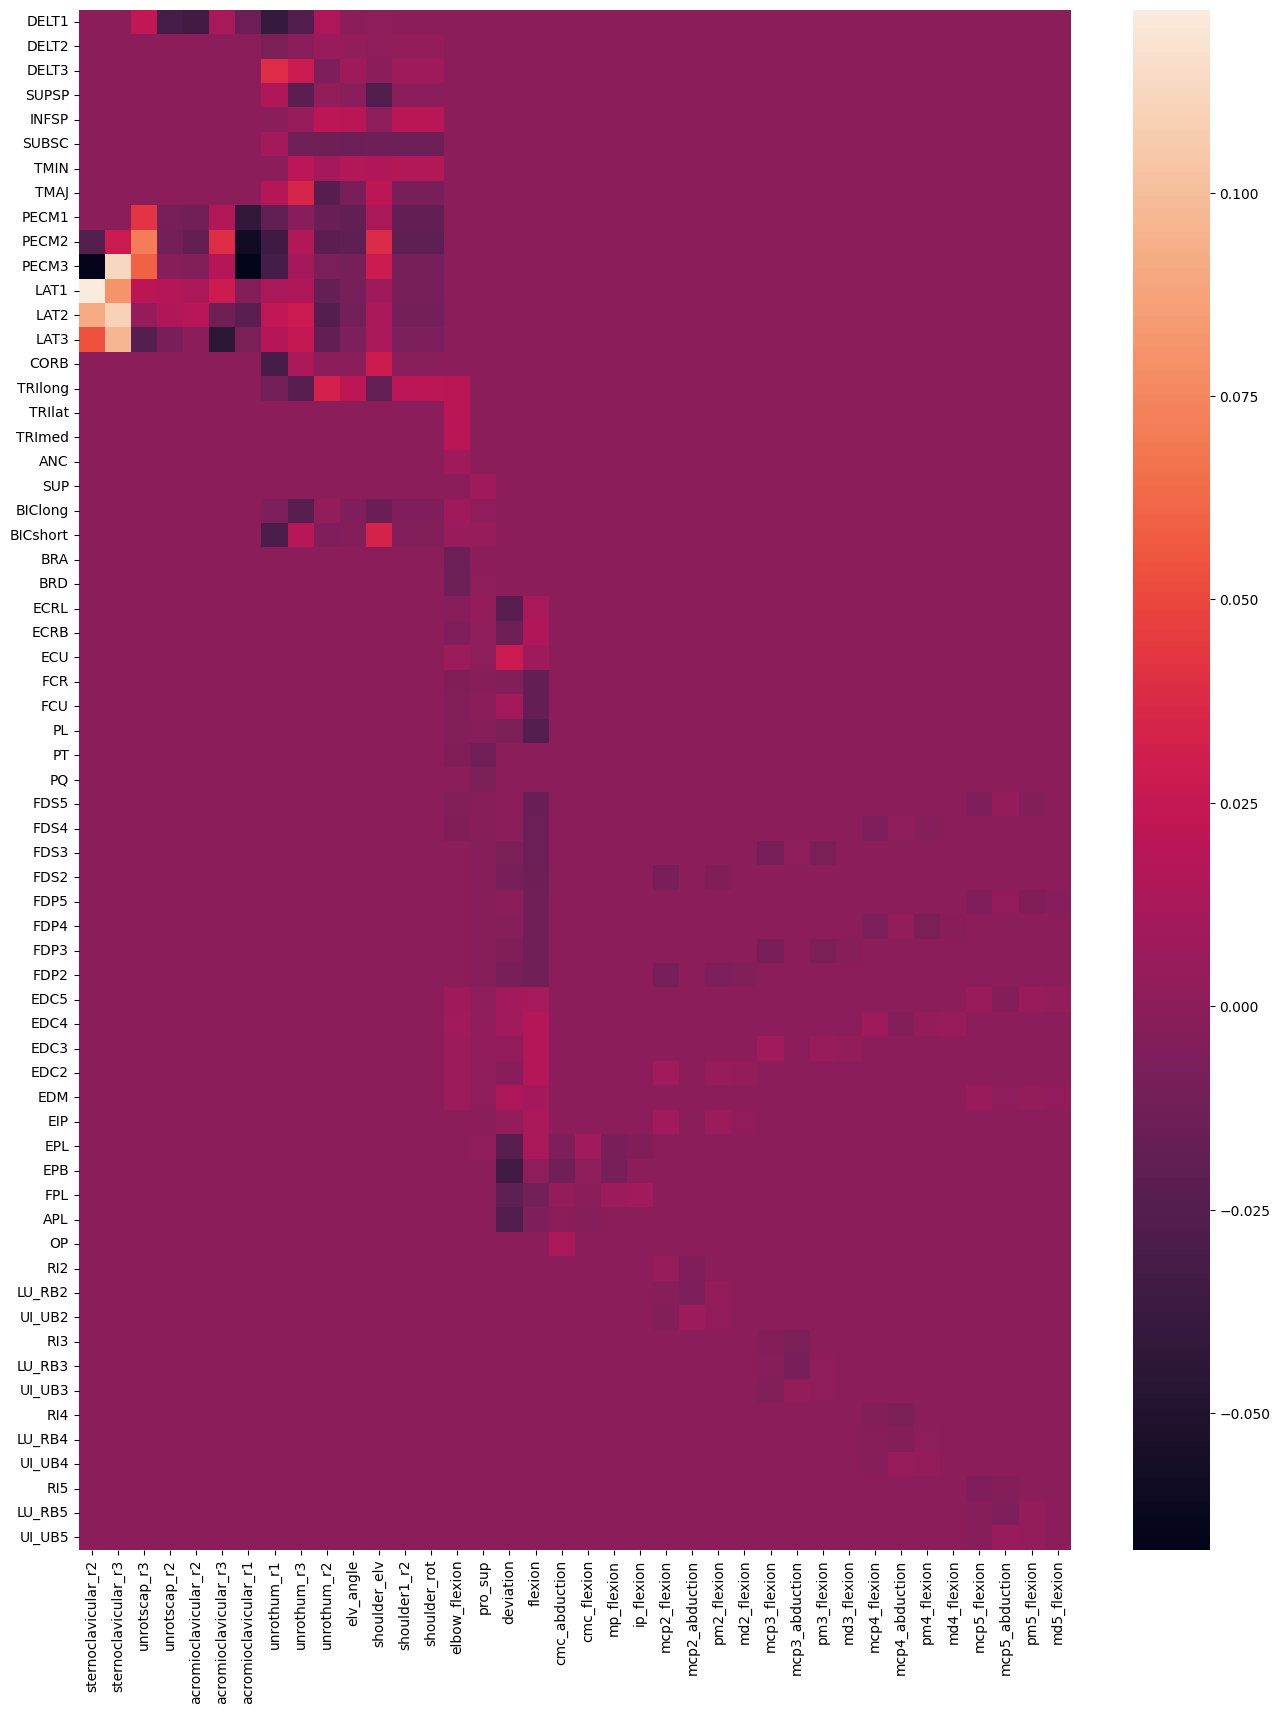

In [21]:
plt.figure(figsize=(16, 20)) 
plt.xticks(np.arange(len(joint_names)) + 0.5, joint_names, rotation = 90)
plt.yticks(np.arange(len(muscle_names)) + 0.5, muscle_names, rotation = 0)
sns.heatmap(moment_arm)